# 01. EDA — 자원 최적화 AI 데이터셋 (전력사용량·피크 예측)

**목표**: 모델을 만들기 전에 데이터 구조를 이해하고, "어떤 조건에서 전력사용량이 증가하고 Peak가 발생하는가"에 대한 가설을 세운다.

**데이터**: `data/raw/okm_augumented_2021.csv` (KAMP 「자원 최적화 AI 데이터셋」, 2021년 1~9월 시간 단위 데이터)


## 0. 환경 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['axes.unicode_minus'] = False
# Windows 환경 한글 폰트 (없으면 그래프의 한글 라벨이 깨질 수 있음 — 필요 시 설치된 폰트명으로 교체)
plt.rcParams['font.family'] = 'Malgun Gothic'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

RAW_PATH = '../data/raw/okm_augumented_2021.csv'
df = pd.read_csv(RAW_PATH, encoding='utf-8-sig')
df.shape


(6168, 18)

## 1. 기본 구조 확인

행/열 수, 컬럼명, 데이터 타입을 먼저 확인한다.


In [2]:
df.head()


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5


In [3]:
df.tail()


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
6163,20210914,19,152,151,171,139,153,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5
6164,20210914,20,124,130,128,130,128,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5
6165,20210914,21,134,130,125,124,128,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5
6166,20210914,22,100,109,120,114,111,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5
6167,20210914,23,117,119,112,91,110,405,22.0,2.5,79,9.4,167.2,2,14,9,0.922551,1.5


In [4]:
df.dtypes


날짜            int64
시간            int64
15분           int64
30분           int64
45분           int64
60분           int64
평균            int64
생산량           int64
기온          float64
풍속          float64
습도            int64
강수량         float64
전기요금(계절)    float64
day           int64
d             int64
m             int64
공장인원        float64
인건비         float64
dtype: object

### 컬럼 의미 (1차 확인 결과)

원본 데이터에 설명 문서가 없어 값의 패턴을 직접 확인해 추정한 의미다. **추정치는 아래 표에 명시했고, 뒤에서 검증 코드로 확인한다.**

| 컬럼 | 의미(추정) | 비고 |
|---|---|---|
| 날짜 | YYYYMMDD 형식 날짜 | |
| 시간 | 해당 시간대(0~23시) | ⚠️ 일부 행에서 0~23 범위를 벗어남 (아래 3장에서 확인) |
| 15분/30분/45분/60분 | 해당 시간 내 15분 간격 전력사용량 4개 측정치 | 단위 미상(원본 문서 없음), kW로 추정 |
| 평균 | 위 4개 값의 평균 = 해당 시간의 대표 전력사용량 | **예측 Target 후보** |
| 생산량 | 해당 시간의 생산량 | |
| 기온/풍속/습도/강수량 | 기상 데이터 | |
| 전기요금(계절) | 계절별 전기요금 단가 | 고유값 3개뿐 → 사실상 범주형 |
| day | 요일 (1~7) | ⚠️ 실제 날짜의 요일과 불일치하는 구간 존재 (3장 확인) |
| d | 일 (1~31) | |
| m | 월 (1~9) | 2021년 1~9월 데이터 |
| 공장인원 | 공장 가동인원 관련 지표 | 정수가 아닌 스케일된 값, 약 43%가 0 |
| 인건비 | 인건비 | 고유값 2개(1.0 / 1.5)뿐 → 사실상 범주형 |

**설비 정보(설비 A/B/C 등 개별 설비 가동 여부), 제품 종류 컬럼은 이 데이터셋에 존재하지 않는다.** 이후 피크 저감 시나리오를 설계할 때 "설비 단위" 조정은 이 데이터로는 만들 수 없고, "생산량/전기요금 구간" 단위로만 접근 가능하다는 점을 미리 인지해야 한다.


## 2. 결측치 · 중복행 확인

In [5]:
df.isnull().sum()


날짜           0
시간           0
15분          0
30분          0
45분          0
60분          0
평균           0
생산량          0
기온           0
풍속           3
습도           0
강수량          1
전기요금(계절)     0
day          0
d            0
m            0
공장인원        17
인건비          0
dtype: int64

In [6]:
print('중복행 수:', df.duplicated().sum())


중복행 수: 0


**확인 결과**: `풍속` 3건, `강수량` 1건, `공장인원` 17건 결측. 행 삭제 대신 보간(시간 순서 기반 `interpolate` 등)을 `02_preprocessing.ipynb`에서 처리하는 걸 권장 — 결측 비율이 낮고(전체 6168행 대비 1% 미만) 시계열이므로 임의 대체보다 주변 시점 기반 보간이 안전하다.

## 3. 데이터 품질 이슈 확인 — `시간` 컬럼 이상값

`시간`이 항상 0~23이어야 하는데 실제로는 그런지 검증한다.


In [7]:
print('시간 컬럼 범위:', df['시간'].min(), '~', df['시간'].max())

bad_hour = df[(df['시간'] < 0) | (df['시간'] > 23)]
print('0~23 범위를 벗어난 행 수:', len(bad_hour))
print('영향받는 날짜:', sorted(bad_hour['날짜'].unique()))
bad_hour[['날짜', '시간', '평균', '생산량']].head(10)


시간 컬럼 범위: 0 ~ 188
0~23 범위를 벗어난 행 수: 48
영향받는 날짜: [np.int64(20210713), np.int64(20210715)]


,날짜,시간,평균,생산량
4632,20210713,70,69,0
4633,20210713,89,96,0
4634,20210713,90,112,0
4635,20210713,97,110,0
4636,20210713,107,106,0
4637,20210713,108,143,0
4638,20210713,112,123,0
4639,20210713,113,111,0
4640,20210713,115,102,0
4641,20210713,118,112,0


**확인 결과**: 2021-07-13, 2021-07-15 근처 48개 행에서 `시간` 값이 70~188 범위로 비정상이다. 원인은 알 수 없음(원본 데이터 자체의 오류로 추정). 이 행들을 `날짜+시간`으로 datetime을 만들면 잘못된 시각이 되어 다른 날짜와 충돌(중복 timestamp)한다 — 아래에서 확인한다.

**처리 방향(제안)**: 이 48개 행은 시각을 신뢰할 수 없으므로 전처리 단계에서 제외하거나, 같은 날짜 내 행 순서(정렬)를 기준으로 시간을 재계산하는 방법을 검토한다. 임의로 고치기보다 우선 팀 내에서 이 처리 방식에 합의하고 README에 근거를 기록한다.


In [8]:
df['dt'] = pd.to_datetime(df['날짜'].astype(str), format='%Y%m%d') + pd.to_timedelta(df['시간'], unit='h')

dup_dt = df[df['dt'].duplicated(keep=False)]
print('dt 기준 중복 행 수:', len(dup_dt))

full_range = pd.date_range(df['dt'].min(), df['dt'].max(), freq='h')
missing = full_range.difference(df['dt'])
print('기대되는 총 시간 수:', len(full_range), '/ 실제 고유 dt 수:', df['dt'].nunique())
print('완전히 비어있는 시간대 수:', len(missing))


dt 기준 중복 행 수: 87
기대되는 총 시간 수: 6168 / 실제 고유 dt 수: 6121
완전히 비어있는 시간대 수: 47


## 4. 시계열 정렬 및 전체 기간 전력사용량 추이

우선 이상값 48행을 제외한 뒤 시간순으로 정렬해서 전체 흐름을 본다. (완전한 정제는 `02_preprocessing.ipynb`에서 진행 — 여기서는 EDA 목적의 임시 필터링만 수행)


(6120, 19)


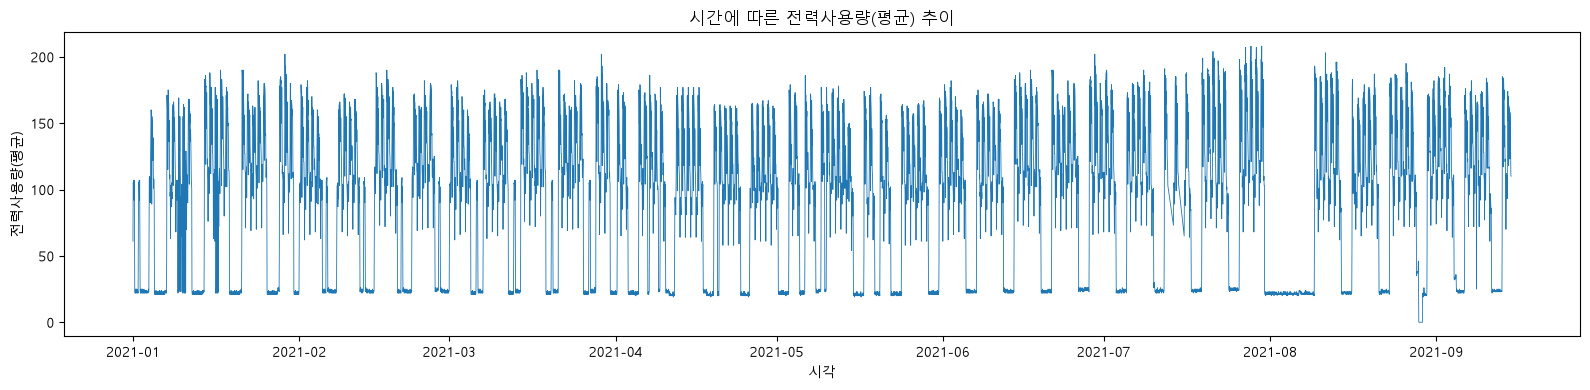

In [9]:
df_clean = df[(df['시간'] >= 0) & (df['시간'] <= 23)].sort_values('dt').reset_index(drop=True)
print(df_clean.shape)

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_clean['dt'], df_clean['평균'], linewidth=0.6)
ax.set_title('시간에 따른 전력사용량(평균) 추이')
ax.set_xlabel('시각')
ax.set_ylabel('전력사용량(평균)')
plt.tight_layout()
plt.savefig('../outputs/figures/01_power_timeseries.png', dpi=120)
plt.show()


## 5. 시간대별 / 요일별 / 월별 평균 전력사용량

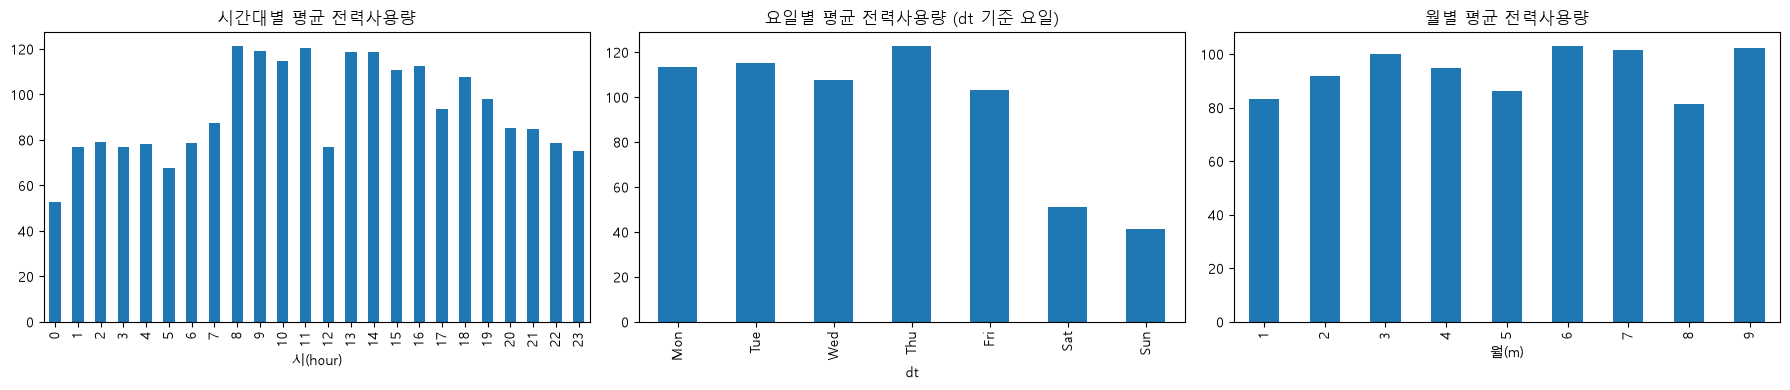

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

df_clean.groupby('시간')['평균'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('시간대별 평균 전력사용량')
axes[0].set_xlabel('시(hour)')

day_name_map = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
by_weekday = df_clean.groupby(df_clean['dt'].dt.dayofweek + 1)['평균'].mean()
by_weekday.index = by_weekday.index.map(day_name_map)
by_weekday.plot(kind='bar', ax=axes[1])
axes[1].set_title('요일별 평균 전력사용량 (dt 기준 요일)')

df_clean.groupby('m')['평균'].mean().plot(kind='bar', ax=axes[2])
axes[2].set_title('월별 평균 전력사용량')
axes[2].set_xlabel('월(m)')

plt.tight_layout()
plt.savefig('../outputs/figures/02_time_group_power.png', dpi=120)
plt.show()


> 원본 `day` 컬럼은 시간 이상값 때문에 일부 구간에서 실제 요일과 어긋날 수 있어, 위 요일별 집계는 `dt.dt.dayofweek`(datetime에서 직접 계산한 요일)로 계산했다. 원본 `day` 컬럼을 신뢰할지는 전처리 단계에서 별도로 검증한다.

## 6. 생산량과 전력사용량의 관계

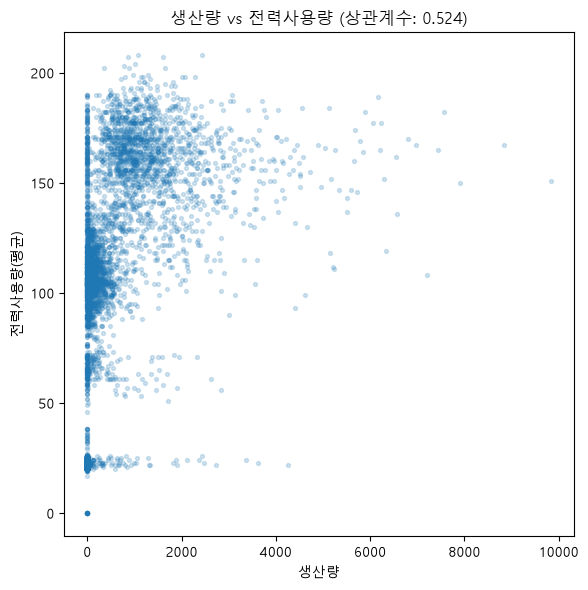

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df_clean['생산량'], df_clean['평균'], alpha=0.2, s=8)
ax.set_xlabel('생산량')
ax.set_ylabel('전력사용량(평균)')
ax.set_title(f"생산량 vs 전력사용량 (상관계수: {df_clean['생산량'].corr(df_clean['평균']):.3f})")
plt.tight_layout()
plt.savefig('../outputs/figures/03_production_vs_power.png', dpi=120)
plt.show()


생산량이 0인 행이 전체의 약 43%다(비가동 시간대로 추정). 생산량 0 구간과 0 초과 구간을 나눠서 관계를 다시 보는 것도 의미가 있다.

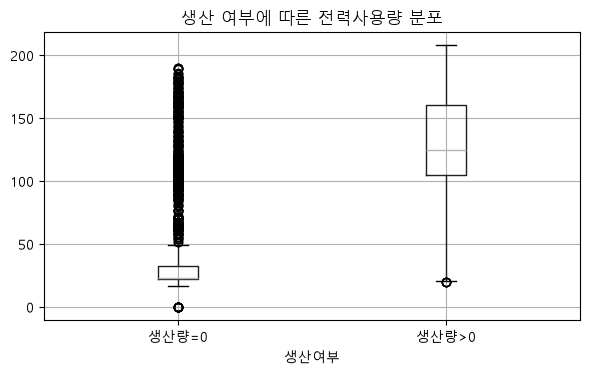

In [12]:
df_clean['생산여부'] = (df_clean['생산량'] > 0).map({True: '생산량>0', False: '생산량=0'})

fig, ax = plt.subplots(figsize=(6, 4))
df_clean.boxplot(column='평균', by='생산여부', ax=ax)
ax.set_title('생산 여부에 따른 전력사용량 분포')
plt.suptitle('')
plt.tight_layout()
plt.show()


## 7. 기상 변수와 전력사용량의 관계

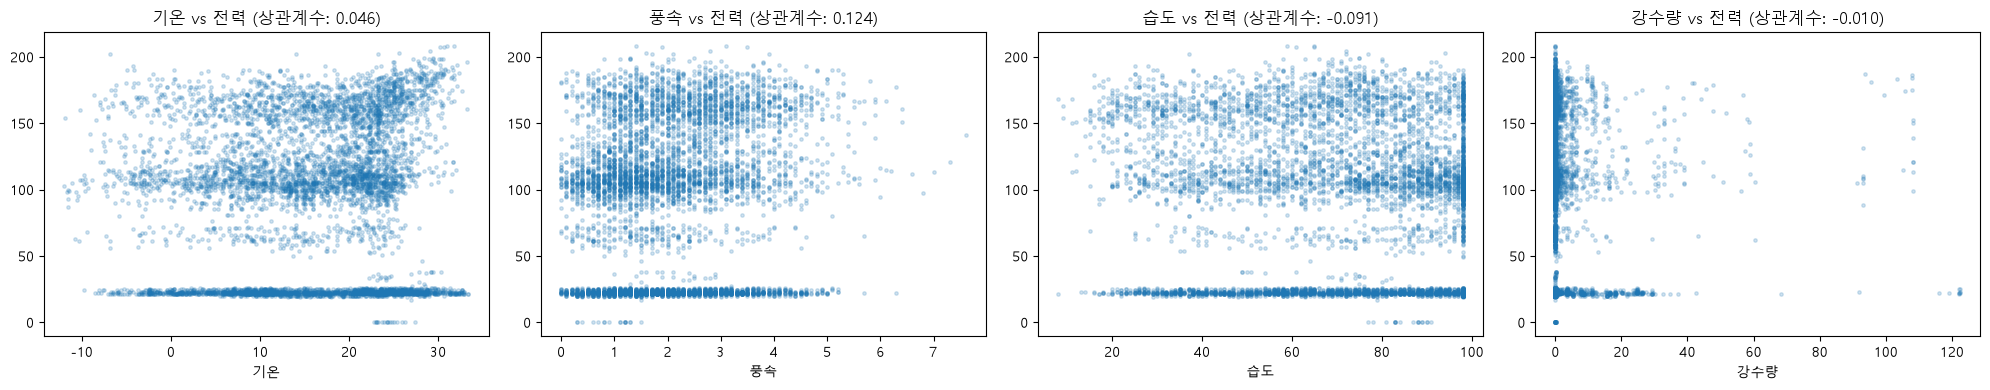

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, col in zip(axes, ['기온', '풍속', '습도', '강수량']):
    ax.scatter(df_clean[col], df_clean['평균'], alpha=0.2, s=6)
    ax.set_title(f'{col} vs 전력 (상관계수: {df_clean[col].corr(df_clean["평균"]):.3f})')
    ax.set_xlabel(col)
plt.tight_layout()
plt.savefig('../outputs/figures/04_weather_vs_power.png', dpi=120)
plt.show()


## 8. 전기요금(계절) 구간별 / 공장인원·인건비별 전력사용량

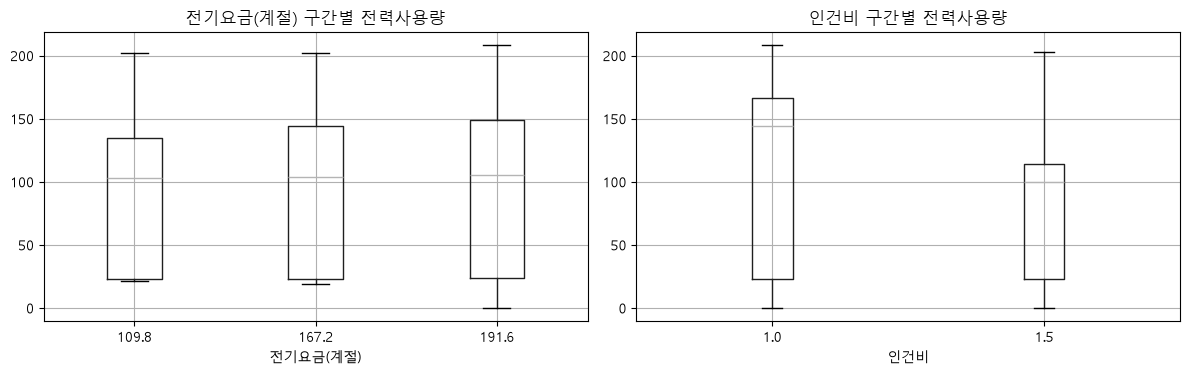

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_clean.boxplot(column='평균', by='전기요금(계절)', ax=axes[0])
axes[0].set_title('전기요금(계절) 구간별 전력사용량')

df_clean.boxplot(column='평균', by='인건비', ax=axes[1])
axes[1].set_title('인건비 구간별 전력사용량')
plt.suptitle('')
plt.tight_layout()
plt.show()


## 9. 변수 간 상관관계

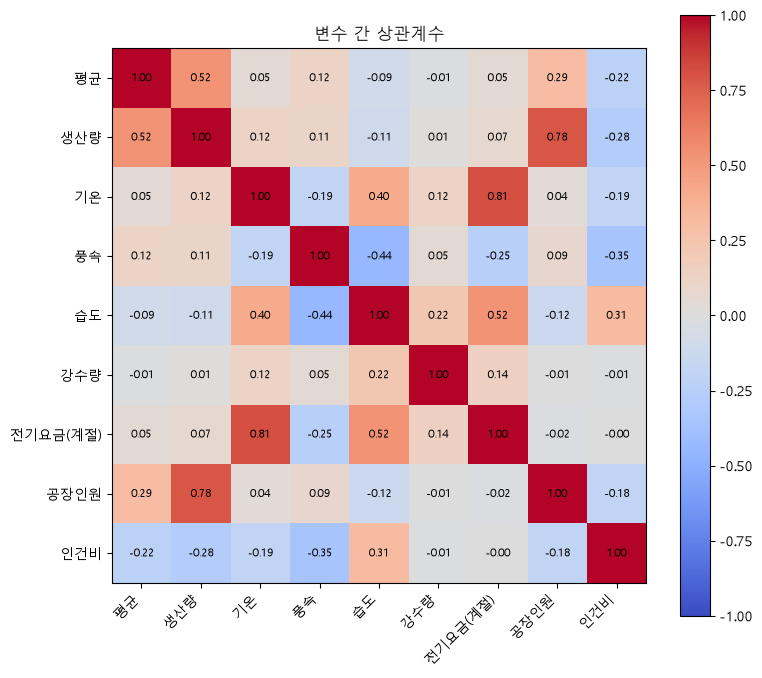

In [15]:
num_cols = ['평균', '생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', '공장인원', '인건비']
corr = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im)
ax.set_title('변수 간 상관계수')
plt.tight_layout()
plt.savefig('../outputs/figures/05_correlation_heatmap.png', dpi=120)
plt.show()


## 10. Peak 조건 탐색

우선 상위 10%를 Peak 기준으로 잡고, 일반 구간과 비교해 어떤 조건에서 Peak가 몰리는지 확인한다. (최종 기준은 공모전 요구사항이나 모델링 단계에서 재조정 가능)


In [16]:
peak_threshold = df_clean['평균'].quantile(0.9)
df_clean['is_peak'] = df_clean['평균'] >= peak_threshold
print('Peak 기준값(상위 10%):', peak_threshold)
print('Peak 행 수:', df_clean['is_peak'].sum(), '/', len(df_clean))


Peak 기준값(상위 10%): 169.0
Peak 행 수: 630 / 6120


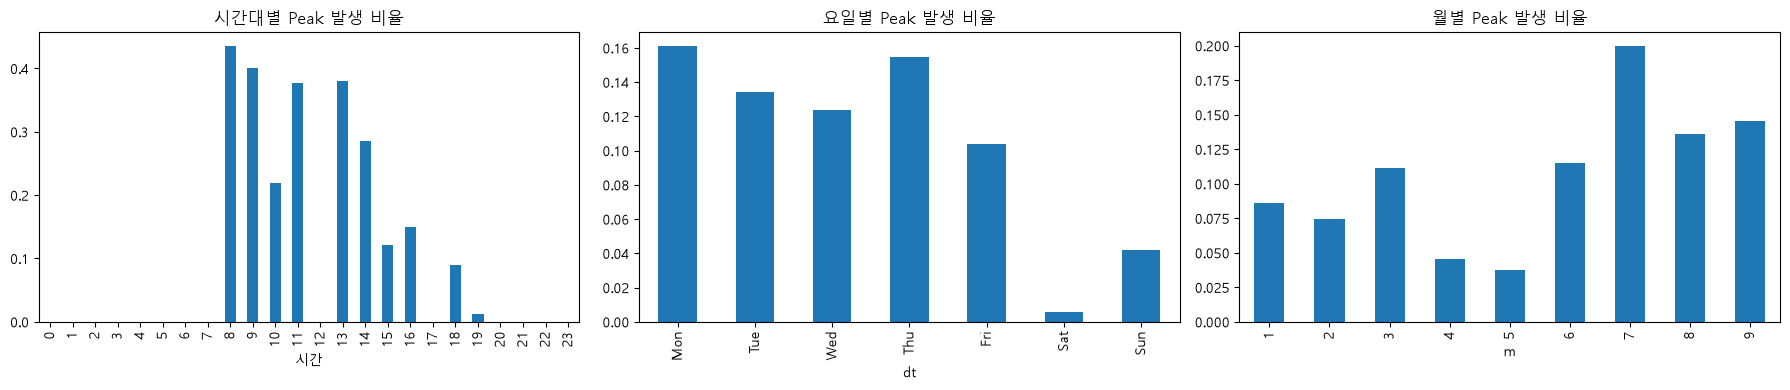

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

df_clean.groupby('시간')['is_peak'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('시간대별 Peak 발생 비율')

by_weekday_peak = df_clean.groupby(df_clean['dt'].dt.dayofweek + 1)['is_peak'].mean()
by_weekday_peak.index = by_weekday_peak.index.map(day_name_map)
by_weekday_peak.plot(kind='bar', ax=axes[1])
axes[1].set_title('요일별 Peak 발생 비율')

df_clean.groupby('m')['is_peak'].mean().plot(kind='bar', ax=axes[2])
axes[2].set_title('월별 Peak 발생 비율')

plt.tight_layout()
plt.savefig('../outputs/figures/06_peak_condition.png', dpi=120)
plt.show()


In [18]:
print('Peak 구간 생산량 평균:', df_clean.loc[df_clean['is_peak'], '생산량'].mean())
print('일반 구간 생산량 평균:', df_clean.loc[~df_clean['is_peak'], '생산량'].mean())
print()
print('Peak 구간 기온 평균:', df_clean.loc[df_clean['is_peak'], '기온'].mean())
print('일반 구간 기온 평균:', df_clean.loc[~df_clean['is_peak'], '기온'].mean())


Peak 구간 생산량 평균: 1200.0857142857142
일반 구간 생산량 평균: 387.3457194899818

Peak 구간 기온 평균: 19.25984126984127
일반 구간 기온 평균: 15.42032786885246


## 11. EDA 요약 — 다음 단계로 넘길 가설과 확인 사항

**가설 (검증 필요, 상관관계≠인과관계)**
- 전력사용량은 생산량과 양의 상관관계를 보이나, 생산량=0(비가동)에서도 base load가 존재한다 — 예측 모델은 이 base load를 분리해서 다룰 필요가 있다.
- 시간대/요일에 따라 전력사용량과 Peak 발생 비율에 뚜렷한 패턴이 있다 → `hour`, `weekday` 계열 feature는 예측에 유효할 것으로 보인다.
- 전기요금(계절) 구간이 사실상 계절 구분(3단계)과 같은 역할을 할 수 있음 → 월/계절 feature와 다중공선성 여부를 모델링 단계에서 점검.

**데이터 품질 이슈 (전처리 단계에서 반드시 처리)**
1. `시간` 컬럼이 0~23을 벗어나는 행 48개(2021-07-13, 07-15 부근) — 처리 방식 팀 논의 필요.
2. `풍속`(3) · `강수량`(1) · `공장인원`(17) 결측치 — 시간 순서 기반 보간 권장.
3. 원본 `day`(요일) 컬럼이 `날짜`에서 계산한 실제 요일과 일부 구간에서 불일치 — 원본을 쓸지 재계산할지 결정 필요.

**설비 정보 부재 — 8단계(Peak 저감 시뮬레이션) 설계에 영향**
- 이 데이터셋에는 설비별 가동 여부/개별 설비 전력 데이터가 없다. 따라서 "설비 A/B/C 동시가동" 같은 설비 단위 시나리오는 이 데이터로 구현할 수 없다.
- 대신 시간 단위로 존재하는 `생산량`, `전기요금(계절)`을 활용해 "생산량 시간대 분산" 시나리오는 시도 가능 — `08_optimization` 단계에서 이 제약을 반영해 시나리오를 재설계해야 한다.

**다음 단계**: `02_preprocessing.ipynb`에서 위 품질 이슈를 정리하고, datetime 인덱스 기반 정렬된 클린 데이터를 `data/processed/`에 저장한다.
